# 5 — Source Localization

This notebook covers **source localization** for the passive auditory oddball OPM-MEG dataset using an **LCMV beamformer**.

It is structured in two halves:
1. **Pipeline Status Check** — verify which upstream steps (FreeSurfer, BEM, source space, forward model, covariance) have already been completed by `run_freesurfer.sh` and `run_preproc.sh`, and visualize their outputs.
2. **LCMV Beamformer** — compute spatial filters from the data covariance and apply them to the MMN evoked response to produce focal source-space estimates.

---
## What the pipeline already ran for us

| Script | Step | Output |
|--------|------|--------|
| `run_freesurfer.sh` | `recon-all` | FreeSurfer surfaces (`lh/rh.white`, `pial`, etc.) |
| `run_freesurfer.sh` | `mne watershed_bem` | BEM surface meshes (inner skull, outer skull, scalp) |
| `run_freesurfer.sh` | `mkheadsurf` | Hi-res scalp surface for coregistration |
| `run_preproc.sh` | `source/make_bem_solution` | BEM solution `.fif` (physics solved) |
| `run_preproc.sh` | `source/setup_source_space` | Source space `.fif` (candidate dipole locations) |
| `run_preproc.sh` | `source/make_forward` | Forward solution `.fif` (leadfield matrix) |
| `run_preproc.sh` | `sensor/make_evoked` | Evoked responses `.fif` |
| `run_preproc.sh` | `sensor/make_cov` | Noise covariance `.fif` |

**What's left (this notebook):** data covariance → LCMV filters → source estimates → visualization.


---
# 0. Configuration
Edit these paths to match your local setup.

In [2]:
import os
from pathlib import Path

# ── Edit these if running a different subject/session ───────────────────────
SUBJECT     = "001"          # without 'sub-' prefix
SESSION     = "01"           # without 'ses-' prefix
TASK        = "oddball"      # task label used in BIDS filenames
ANALYSIS    = "analysis1__"  # name of the derivatives analysis folder

PROJECT_ROOT = Path("/Users/markpinsk/opm-projects/oddball")
BIDS_DIR     = PROJECT_ROOT / "data" / "oddball" / "bids"
SUBJECTS_DIR = BIDS_DIR / "derivatives" / "freesurfer"  # adjust if FS lives elsewhere
# ────────────────────────────────────────────────────────────────────────────

# Derived
sub_label   = f"sub-{SUBJECT}"
ses_label   = f"ses-{SESSION}"
fs_subject  = f"sub-{SUBJECT}_ses-{SESSION}"     # FreeSurfer subject folder name

# MNE-BIDS-Pipeline derivatives directory
DERIV_DIR = BIDS_DIR / "derivatives" / ANALYSIS / sub_label / ses_label / "meg"
FS_SUBJ_DIR = SUBJECTS_DIR / fs_subject

print(f"Subject:       {sub_label}")
print(f"Session:       {ses_label}")
print(f"FS subject:    {fs_subject}")
print(f"Derivatives:   {DERIV_DIR}")
print(f"FreeSurfer:    {FS_SUBJ_DIR}")

Subject:       sub-001
Session:       ses-01
FS subject:    sub-001_ses-01
Derivatives:   /Users/markpinsk/opm-projects/oddball/data/oddball/bids/derivatives/analysis1__/sub-001/ses-01/meg
FreeSurfer:    /Users/markpinsk/opm-projects/oddball/data/oddball/bids/derivatives/freesurfer/sub-001_ses-01


---
# 1. Pipeline Status Check
Check whether each expected output file from the pipeline actually exists on disk.

In [3]:
# ── Helper ──────────────────────────────────────────────────────────────────
def check(label, path):
    """Print a coloured status line for a pipeline output."""
    path = Path(path)
    exists = path.exists()
    icon   = "✅" if exists else "❌"
    size   = f"  ({path.stat().st_size / 1e6:.1f} MB)" if exists else ""
    print(f"{icon}  {label:50s}  {path.name}{size}")
    return exists

status = {}  # collect pass/fail for summary

# ── 1a. FreeSurfer recon-all ─────────────────────────────────────────────────
print("\n── FreeSurfer recon-all ──────────────────────────────────────────")
fs_files = {
    "T1.mgz (orig volume)"          : FS_SUBJ_DIR / "mri" / "T1.mgz",
    "brain.mgz (skull-stripped)"    : FS_SUBJ_DIR / "mri" / "brain.mgz",
    "lh.white (left white matter)"  : FS_SUBJ_DIR / "surf" / "lh.white",
    "rh.white (right white matter)" : FS_SUBJ_DIR / "surf" / "rh.white",
    "lh.pial (left pial surface)"   : FS_SUBJ_DIR / "surf" / "lh.pial",
    "rh.pial (right pial surface)"  : FS_SUBJ_DIR / "surf" / "rh.pial",
    "lh.inflated"                   : FS_SUBJ_DIR / "surf" / "lh.inflated",
    "rh.inflated"                   : FS_SUBJ_DIR / "surf" / "rh.inflated",
    "aparc annot (Desikan lh)"       : FS_SUBJ_DIR / "label" / "lh.aparc.annot",
    "aparc annot (Desikan rh)"       : FS_SUBJ_DIR / "label" / "rh.aparc.annot",
}
for label, path in fs_files.items():
    status[label] = check(label, path)

# ── 1b. BEM surfaces (from watershed_bem) ────────────────────────────────────
print("\n── BEM surfaces (watershed_bem) ──────────────────────────────────")
bem_dir = FS_SUBJ_DIR / "bem" / "watershed"
bem_surfs = {
    "inner skull surface"  : bem_dir / f"{fs_subject}_inner_skull_surface",
    "outer skull surface"  : bem_dir / f"{fs_subject}_outer_skull_surface",
    "outer skin surface"   : bem_dir / f"{fs_subject}_outer_skin_surface",
    "brain surface"        : bem_dir / f"{fs_subject}_brain_surface",
}
for label, path in bem_surfs.items():
    status[label] = check(label, path)

# ── 1c. Hi-res scalp surface (mkheadsurf) ────────────────────────────────────
print("\n── Hi-res scalp surface (mkheadsurf) ────────────────────────────")
head_surf = FS_SUBJ_DIR / "surf" / "lh.seghead"
status["hi-res scalp (lh.seghead)"] = check("hi-res scalp (lh.seghead)", head_surf)

# ── 1d. MNE-BIDS pipeline source outputs ─────────────────────────────────────
print("\n── MNE-BIDS Pipeline source outputs ─────────────────────────────")

# MNE-BIDS-pipeline can store source-level files in several locations:
#   1. Per-session meg folder  (DERIV_DIR)           — evoked, cov, fwd
#   2. Subject-level folder    (two levels up)        — sometimes src/bem
#   3. Whole derivatives tree  (analysis1__ root)     — broad fallback
#   4. FreeSurfer bem folder   (FS_SUBJ_DIR/bem)      — bem solution
# We search all of them so nothing gets missed.

SEARCH_ROOTS = [
    DERIV_DIR,                                    # .../analysis1__/sub-001/ses-01/meg
    DERIV_DIR.parent.parent,                      # .../analysis1__/sub-001
    BIDS_DIR / 'derivatives' / ANALYSIS,           # .../analysis1__  (whole tree)
    FS_SUBJ_DIR / 'bem',                           # FreeSurfer bem dir
]

def find_deriv(pattern, roots=None):
    """Search multiple roots for a file matching a glob pattern.
    Returns the first match, or a dummy Path if nothing found.
    """
    if roots is None:
        roots = SEARCH_ROOTS
    for root in roots:
        if Path(root).exists():
            matches = sorted(Path(root).rglob(pattern))
            if matches:
                return matches[0]
    return DERIV_DIR / pattern  # dummy — will show as missing

# Each entry: (label, glob pattern, created_by, needed_for)
pipeline_file_info = [
    (
        "BEM solution",
        "*bem*sol*.fif",
        "mne_bids_pipeline --steps=source/make_bem_solution",
        "Viz only (§3b) — already baked into the forward solution",
    ),
    (
        "Source space",
        "*src*.fif",
        "mne_bids_pipeline --steps=source/setup_source_space",
        "Viz only (§3a) — already baked into the forward solution",
    ),
    (
        "Forward solution",
        "*fwd*.fif",
        "mne_bids_pipeline --steps=source/make_forward",
        "⭐ ESSENTIAL — leadfield matrix (sensors × sources); input to inverse operator",
    ),
    (
        "Noise covariance",
        "*cov*.fif",
        "mne_bids_pipeline --steps=sensor/make_cov  (uses empty-room proc-clean)",
        "⭐ ESSENTIAL — sensor noise model; input to inverse operator",
    ),
    (
        "Evoked responses",
        "*ave*.fif",
        "mne_bids_pipeline --steps=sensor/make_evoked",
        "⭐ ESSENTIAL — condition averages (standard, deviant, MMN); what we apply the inverse to",
    ),
]

pipeline_files = {}
for label, pattern, created_by, needed_for in pipeline_file_info:
    path = find_deriv(pattern)
    pipeline_files[label] = path
    found  = path.exists()
    icon   = '✅' if found else '❌'
    size   = f'({path.stat().st_size / 1e6:.1f} MB)' if found else '(NOT FOUND)'
    status[label] = found
    print(f"{icon}  {label}")
    print(f"     Created by : {created_by}")
    print(f"     Needed for : {needed_for}")
    print(f"     Location   : {path}  {size}")
    print()

# ── Summary ───────────────────────────────────────────────────────────────────
n_pass = sum(status.values())
n_total = len(status)
print(f"{'─'*60}")
print(f"  Pipeline status: {n_pass}/{n_total} outputs present")
if n_pass == n_total:
    print("  🎉 All upstream outputs found — ready for source localization!")
else:
    missing = [k for k, v in status.items() if not v]
    print(f"  ⚠️  Missing outputs:")
    for m in missing:
        print(f"       • {m}")



── FreeSurfer recon-all ──────────────────────────────────────────
✅  T1.mgz (orig volume)                                T1.mgz  (3.4 MB)
✅  brain.mgz (skull-stripped)                          brain.mgz  (1.2 MB)
✅  lh.white (left white matter)                        lh.white  (4.6 MB)
✅  rh.white (right white matter)                       rh.white  (4.6 MB)
✅  lh.pial (left pial surface)                         lh.pial  (4.6 MB)
✅  rh.pial (right pial surface)                        rh.pial  (4.6 MB)
✅  lh.inflated                                         lh.inflated  (4.6 MB)
✅  rh.inflated                                         rh.inflated  (4.6 MB)
✅  aparc annot (Desikan lh)                            lh.aparc.annot  (1.0 MB)
✅  aparc annot (Desikan rh)                            rh.aparc.annot  (1.0 MB)

── BEM surfaces (watershed_bem) ──────────────────────────────────
✅  inner skull surface                                 sub-001_ses-01_inner_skull_surface  (0.4 MB)
✅  outer 

---
# 2. Load Pipeline Outputs

In [4]:
import mne
mne.set_log_level('WARNING')  # suppress verbose MNE output

# ── Load source space ────────────────────────────────────────────────────────
src_path = find_deriv("*src*")
src = mne.read_source_spaces(src_path)
print(f"Source space loaded: {src_path.name}")
print(src)

# ── Load forward solution ────────────────────────────────────────────────────
fwd_path = find_deriv("*fwd*")
fwd = mne.read_forward_solution(fwd_path)
print(f"\nForward solution loaded: {fwd_path.name}")
print(fwd)

# ── Load noise covariance ────────────────────────────────────────────────────
cov_path = find_deriv("*cov*")
noise_cov = mne.read_cov(cov_path)
print(f"\nNoise covariance loaded: {cov_path.name}")
print(noise_cov)

# ── Load evoked responses ────────────────────────────────────────────────────
ave_path = find_deriv("*ave*")
evokeds = mne.read_evokeds(ave_path)
print(f"\nEvoked responses loaded: {ave_path.name}")
for ev in evokeds:
    print(f"  • {ev.comment!r:30s}  n_avg={ev.nave}  tmin={ev.tmin:.3f}  tmax={ev.tmax:.3f}")

Source space loaded: sub-001_ses-01-oct6-src.fif
<SourceSpaces: [<surface (lh), n_vertices=126503, n_used=4098>, <surface (rh), n_vertices=126519, n_used=4098>] MRI (surface RAS) coords, subject 'sub-001_ses-01', ~21.5 MiB>

Forward solution loaded: sub-001_ses-01_task-oddball_fwd.fif
<Forward | MEG channels: 192 | EEG channels: 0 | Source space: Surface with 8196 vertices | Source orientation: Free>

Noise covariance loaded: sub-001_ses-01_task-noise_proc-clean_cov.fif
<Covariance | kind : full, shape : (188, 188), range : [-3.1e-24, +9.6e-24], n_samples : 139919>

Evoked responses loaded: sub-001_ses-01_task-oddball_ave.fif
  • 'standard_onset'                n_avg=820  tmin=-0.500  tmax=0.800
  • 'deviant_onset'                 n_avg=168  tmin=-0.500  tmax=0.800
  • 'deviant_onset - standard_onset'  n_avg=139  tmin=-0.500  tmax=0.800


---
# 3. Visualize Upstream Outputs

The following cells visualize the key outputs from the upstream pipeline — FreeSurfer, BEM, forward model, and covariance — before we proceed to source localization. These are important sanity checks: if anything looks wrong here, it will propagate into the source estimates.


## 3a. Source Space — where are the candidate dipoles?

Before we can compute a forward model, we need to decide *where in the brain* to place candidate current sources. We can't model every voxel — we need to discretize the brain into a manageable set of locations. This is the **source space**.

### The two main flavors

**Surface source space** places dipoles only on the **cortical surface** — the thin, folded sheet of grey matter where the vast majority of MEG-detectable neural currents originate. FreeSurfer's `recon-all` reconstructs this surface from the T1 MRI, and MNE samples it at a fixed spacing (typically 5 mm, giving ~4000–5000 sources per hemisphere). Each source is constrained to point perpendicular to the cortical surface, reflecting the columnar organization of pyramidal neurons.

**Volume source space** places dipoles on a regular 3D grid throughout the entire brain volume, including subcortical structures (thalamus, basal ganglia, cerebellum). This is more flexible but comes at a cost: many more source locations, no anatomical constraint on orientation, and noisier estimates because the grid doesn't follow the brain's geometry.

### Why we use the surface source space

For auditory oddball / MMN research the generators are well-established cortical sources (superior temporal gyrus, inferior frontal cortex). The surface source space is appropriate because:

- **Biological validity** — cortical pyramidal neurons are oriented perpendicular to the surface; constraining dipole orientation to the surface normal is physiologically motivated
- **Dimensionality** — ~8000 surface sources vs ~20,000+ volume sources; fewer sources means a better-conditioned inverse problem
- **Parcellation compatibility** — surface source spaces align natively with FreeSurfer's parcellations (Desikan-Killiany, Destrieux), making ROI extraction straightforward
- **Visualization** — source estimates map directly onto the inflated cortical surface, making results intuitive to interpret

The plot below shows the source dipoles as dots on the cortical surface. The spacing between them was set in the pipeline config (`spacing` parameter in `setup_source_space`).


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Print key source space stats
n_lh = src[0]['nuse']
n_rh = src[1]['nuse']
print(f"Source space: {n_lh} sources (LH) + {n_rh} sources (RH) = {n_lh + n_rh} total")
# dist_limit is not always populated — fall back to estimating spacing from vertex positions
dist_limit = src[0]['dist_limit']
if dist_limit is not None:
    spacing_str = f"{dist_limit*1000:.0f} mm (from dist_limit)"
else:
    import numpy as np
    rr = src[0]['rr'][src[0]['vertno']]  # used source positions (m)
    from scipy.spatial import cKDTree
    tree = cKDTree(rr)
    dists, _ = tree.query(rr, k=2)
    spacing_str = f"~{dists[:,1].mean()*1000:.1f} mm (estimated from nearest-neighbour distances)"
print(f"Spacing: {spacing_str} between adjacent sources")

# 3D plot of source space on the white matter surface
fig = mne.viz.plot_alignment(
    subject=fs_subject,
    subjects_dir=SUBJECTS_DIR,
    surfaces={'white': 0.3},  # semi-transparent white matter surface
    src=src,
    coord_frame='mri',
    show_axes=True,
)
mne.viz.set_3d_view(fig, azimuth=180, elevation=70)
print("Source dipoles shown as orange dots on the cortical surface")

Source space: 4098 sources (LH) + 4098 sources (RH) = 8196 total
Spacing: ~3.3 mm (estimated from nearest-neighbour distances) between adjacent sources
Source dipoles shown as orange dots on the cortical surface


## 3b. BEM Surfaces — the head geometry layers

To compute the forward model, MNE needs to know the **geometry of the head** — specifically, the boundaries between different tissue types that have different electrical conductivities. This is captured by the **Boundary Element Model (BEM)**.

### What is the BEM?

The BEM represents the head as a set of nested shells, each defined by a triangulated mesh surface:

| Surface | Boundary | Role |
|---------|----------|------|
| Inner skull | Brain / skull | Most important for MEG; contains all the sources |
| Outer skull | Skull / scalp | More important for EEG (skull is a poor conductor) |
| Outer skin (scalp) | Scalp / air | Outermost boundary |

These surfaces are extracted from the FreeSurfer T1 reconstruction by `mne watershed_bem`, which uses a watershed algorithm to segment tissue boundaries. The surfaces are then used to solve Maxwell's equations numerically — computing how a current dipole inside the head would distribute across the sensor array.

### MEG vs EEG

For **EEG**, all three surfaces matter because current must flow through the poorly-conducting skull, which strongly distorts the electric field. For **MEG** (including OPM-MEG), magnetic fields pass through tissue almost unimpeded, so only the **inner skull surface** has a significant effect. This means MEG BEM models can use a simpler **single-shell** approximation — one surface instead of three — without meaningful loss of accuracy.

### From surfaces to solution

The BEM *surfaces* (meshes) are distinct from the BEM *solution*. The surfaces define the geometry; the solution (`make_bem_solution`) solves the integral equations that describe how current flows across those boundaries. The solution is then used by `make_forward` to compute the leadfield matrix. The plot below overlays the BEM surfaces on slices of the T1 MRI — a good sanity check that watershed segmentation ran correctly.


BEM surfaces overlaid on T1 MRI slices
  Inner skull (yellow) — outer boundary used for single-shell MEG BEM
  White matter surface (grey) — should sit comfortably inside inner skull


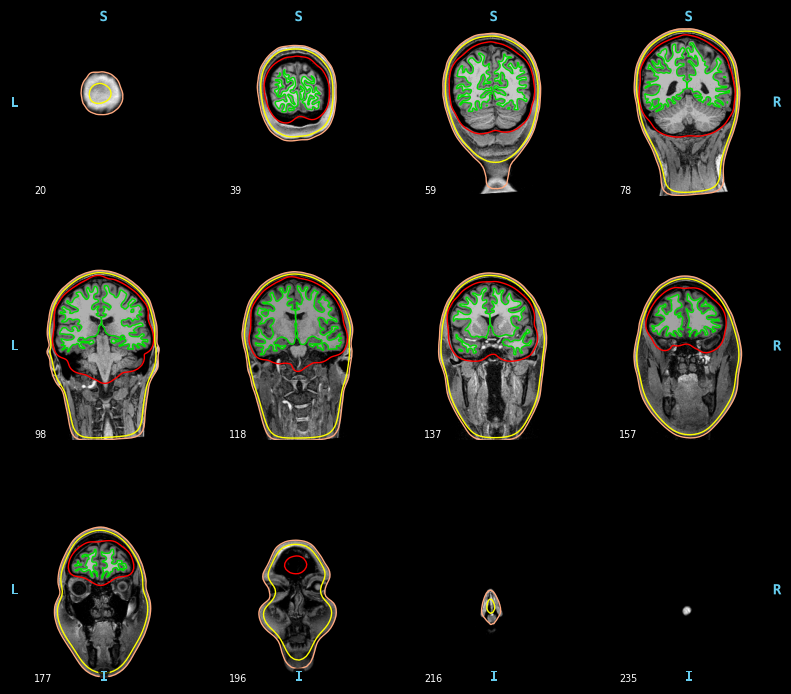

In [6]:
# Load and visualise the BEM surfaces (inner skull, outer skull, outer skin)
# These were created by mne watershed_bem in run_freesurfer.sh
bem_sol_path = find_deriv("*bem-sol*")
bem_sol = mne.read_bem_solution(bem_sol_path)

fig = mne.viz.plot_bem(
    subject=fs_subject,
    subjects_dir=SUBJECTS_DIR,
    brain_surfaces='white',
    orientation='coronal',
    show=False
)
print("BEM surfaces overlaid on T1 MRI slices")
print("  Inner skull (yellow) — outer boundary used for single-shell MEG BEM")
print("  White matter surface (grey) — should sit comfortably inside inner skull")

## 3c. Forward Solution — sensor-to-source sensitivity

### The inverse problem

When we record MEG data, our sensors measure tiny magnetic fields that have leaked out through the skull. What we *want* to know is: **where inside the brain is the activity coming from, and how strong is it?**

Working from sensors → brain sources is called the **inverse problem**, and it is fundamentally ill-posed: infinitely many source configurations can produce identical sensor readings. You cannot solve it without additional constraints or assumptions.

Before we can tackle the inverse problem, we first need to solve the much easier **forward problem**: *if a current source of known strength existed at location X, what signal would each sensor measure?* This can be solved exactly from physics.

### The forward solution and the leadfield matrix

The **forward solution** is the result of solving the forward problem for every candidate source location in the source space. It is stored as the **leadfield matrix** (also called the gain matrix), **G**, with shape:

```
G  :  (n_sensors  ×  n_sources)
```

Each column of G answers the question: *"If a 1 nAm dipole (see note below) fires at source location j, what would every sensor measure?"* Together, the columns describe the full mapping from brain activity to sensor readings.

> **nAm** = nano-Ampere-meter, the unit of current dipole moment. A dipole moment combines current strength (Amperes) and spatial extent (meters). Typical MEG-detectable cortical patches produce dipole moments of 1–100 nAm, corresponding to roughly 10,000–50,000 synchronously active pyramidal neurons.

To compute G, `make_forward` combines three ingredients:

| Ingredient | Provides | Computed by |
|---|---|---|
| Source space | Where the candidate dipoles are | `setup_source_space` |
| BEM solution | Head geometry and tissue conductivity | `make_bem_solution` |
| Coregistration (trans) | Alignment of MRI coords ↔ sensor coords | `mne coreg` |

### What to expect in the sensitivity histogram

The histogram below shows the **sensitivity** of the sensor array to each of the 8196 source locations — computed as the RMS of each column of G. Here is what to expect and look for:

**Shape:** A right-skewed distribution with a long tail. Most sources will cluster at low-to-moderate sensitivity values, with a smaller number of superficial sources producing much higher values. This skew is normal and expected.

**Two rough groups:** You will often see a broad hump of deeper/medial sources at lower sensitivity, and a shoulder or secondary cluster of superficial lateral sources at higher sensitivity. OPM sensors are very close to the scalp, so this contrast between superficial and deep sources is more pronounced than in traditional cryogenic MEG.

**What would be a problem:**
- A flat, uniform distribution — would suggest something went wrong with the forward model (e.g. sensors all at the same distance from sources)
- A bimodal distribution with a large gap — could indicate a coregistration error where some sensors ended up far from the head
- All values near zero — would indicate the leadfield was not computed correctly

The absolute values of the sensitivity depend on your units and sensor type and are less important than the overall shape. The key sanity check is: *do the most sensitive sources correspond to the superficial cortex directly under the sensors?*


Leadfield matrix shape: (192, 8196)  (sensors × sources)
  192 sensors
  8196 source locations

── Sensitivity distribution diagnostics ──────────────────
  Mean:              2.5857e-05
  Std:               1.2456e-05
  Coeff. variation:  0.48  (spread relative to mean)
  Skewness:          0.10  (>0 = right-skewed, expected)
  Kurtosis:          -0.89  (>0 = heavy tails)
  10th percentile:   9.0689e-06
  50th percentile:   2.5831e-05  (median)
  90th percentile:   4.2240e-05
  90th/10th ratio:   4.7x  (superficial vs deep contrast)

── Interpretation ────────────────────────────────────────────
  ⚠️  Skewness (0.10): mildly right-skewed — less pronounced than typical; check sensor-scalp distances
  ⚠️  90th/10th ratio (4.7x): modest contrast — may indicate sensors are farther from scalp than expected
  ✅ No large cluster of near-zero sensitivities


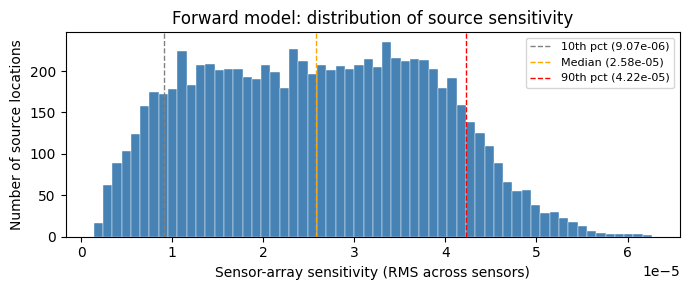

In [7]:
# Convert to fixed-orientation (surface-normal dipoles) if not already
fwd_fixed = mne.convert_forward_solution(fwd, surf_ori=True, force_fixed=True, verbose=False)

# Leadfield matrix: shape = (n_sensors, n_sources)
G = fwd_fixed['sol']['data']
print(f'Leadfield matrix shape: {G.shape}  (sensors × sources)')
print(f'  {G.shape[0]} sensors')
print(f'  {G.shape[1]} source locations')

# Sensitivity map: RMS across sensors for each source
sensitivity = np.linalg.norm(G, axis=0)

# ── Assess distribution shape ─────────────────────────────────────────────────
from scipy import stats

skewness  = stats.skew(sensitivity)
kurt      = stats.kurtosis(sensitivity)
cv        = sensitivity.std() / sensitivity.mean()   # coefficient of variation
p10, p50, p90 = np.percentile(sensitivity, [10, 50, 90])
spread_ratio  = p90 / p10  # ratio of high to low sensitivity

print(f'\n── Sensitivity distribution diagnostics ──────────────────')
print(f'  Mean:              {sensitivity.mean():.4e}')
print(f'  Std:               {sensitivity.std():.4e}')
print(f'  Coeff. variation:  {cv:.2f}  (spread relative to mean)')
print(f'  Skewness:          {skewness:.2f}  (>0 = right-skewed, expected)')
print(f'  Kurtosis:          {kurt:.2f}  (>0 = heavy tails)')
print(f'  10th percentile:   {p10:.4e}')
print(f'  50th percentile:   {p50:.4e}  (median)')
print(f'  90th percentile:   {p90:.4e}')
print(f'  90th/10th ratio:   {spread_ratio:.1f}x  (superficial vs deep contrast)')

print(f'\n── Interpretation ────────────────────────────────────────────')

# Skewness check
if skewness > 1.0:
    print(f'  ✅ Skewness ({skewness:.2f}): right-skewed — expected; superficial sources'
          f' dominate the upper tail')
elif skewness > 0:
    print(f'  ⚠️  Skewness ({skewness:.2f}): mildly right-skewed — less pronounced than'
          f' typical; check sensor-scalp distances')
else:
    print(f'  ❌ Skewness ({skewness:.2f}): not right-skewed — unexpected; may indicate'
          f' a forward model or coregistration problem')

# Spread check
if spread_ratio > 5:
    print(f'  ✅ 90th/10th ratio ({spread_ratio:.1f}x): healthy contrast between'
          f' superficial and deep sources')
elif spread_ratio > 2:
    print(f'  ⚠️  90th/10th ratio ({spread_ratio:.1f}x): modest contrast — may indicate'
          f' sensors are farther from scalp than expected')
else:
    print(f'  ❌ 90th/10th ratio ({spread_ratio:.1f}x): very flat — all sources appear'
          f' equally sensitive, which is not physically realistic')

# Near-zero check
near_zero = np.mean(sensitivity < sensitivity.mean() * 0.01)
if near_zero > 0.1:
    print(f'  ❌ {near_zero*100:.1f}% of sources have near-zero sensitivity —'
          f' possible forward model failure')
else:
    print(f'  ✅ No large cluster of near-zero sensitivities')

# ── Plot histogram ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(sensitivity, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(p10, color='grey',   linestyle='--', lw=1, label=f'10th pct ({p10:.2e})')
ax.axvline(p50, color='orange', linestyle='--', lw=1, label=f'Median ({p50:.2e})')
ax.axvline(p90, color='red',    linestyle='--', lw=1, label=f'90th pct ({p90:.2e})')
ax.set_xlabel('Sensor-array sensitivity (RMS across sensors)')
ax.set_ylabel('Number of source locations')
ax.set_title('Forward model: distribution of source sensitivity')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3d. Noise Covariance — characterizing sensor noise

### What is it?

The **noise covariance matrix** is a (n_sensors × n_sensors) matrix that describes the statistical structure of the background noise in the sensor array — how noisy each sensor is, and how correlated the noise is between sensors. It is estimated from the **empty-room recording**: a short recording made with the OPM helmet in place but no subject present, capturing only the ambient magnetic environment and sensor electronics.

### How was it created?

There is a subtle pipeline workaround involved. `mne_bids_pipeline` filters the empty-room data (producing a `proc-filt` file) but does **not** apply ICA to it — ICA is only run on subject data. However, `make_cov` looks specifically for a `proc-clean` empty-room file, which is never automatically created. To bridge this gap, `run_preproc.sh` manually copies `proc-filt → proc-clean` for the empty-room recording so that `make_cov` can find it. This is a known gap in `mne-bids-pipeline`'s handling of empty-room data, not a problem specific to this dataset.

### How is it used?

The noise covariance is used in two ways:

- **In minimum-norm methods (MNE, dSPM, sLORETA):** it is a required input to `make_inverse_operator`, where it defines the noise model used to regularize the inverse solution
- **In beamformers (LCMV):** it is passed to `make_lcmv` for **NAI (Neural Activity Index) normalization** — the beamformer divides each source estimate by the projected noise level at that location, correcting for the tendency to overestimate superficial sources and producing a normalized, interpretable output

### What to look for in the plots

**Covariance matrix (left panel):** Should be roughly diagonal — sensors that are physically far apart should have low covariance. Strong off-diagonal structure indicates correlated noise (e.g. environmental interference) that was not fully removed by HFC or ZCA preprocessing.

**Singular value spectrum (right panel):** This is the more informative of the two plots. The singular values tell you how many independent dimensions of information your sensor array actually contains. Here is how to interpret the typical pattern you will see with OPM-MEG data:

- **Smooth decay (early components):** The first ~150–170 singular values should decay gradually and smoothly. These represent genuine noise dimensions — real spatial patterns of electromagnetic interference that vary in magnitude. A smooth decay is healthy and expected.

- **Sudden drop (the effective rank):** At some index you will see a sharp cliff — typically a drop of two or more orders of magnitude over just a few components. This marks the **effective rank** of your data: the number of truly independent sensor dimensions. Below this point, singular values represent numerical noise rather than real signal structure. For OPM-MEG after HFC and ICA, this typically falls 10–20 components below the total channel count.

- **Flat plateau before the red line:** Between the cliff and the hard rank cutoff (red dashed line) you may see a short plateau of near-flat, low singular values. These components are not identically zero — the empty-room recording has some variance in every dimension — but they carry no meaningful structure. They exist because the rank deficiency is gradual rather than perfectly sharp in real data.

- **Hard cutoff at the red line (rank = N):** MNE estimates the data rank and draws a red dashed line at that value. Components to the right of this line are treated as zero — they correspond to dimensions that were eliminated by preprocessing steps. The most common causes are:
  - **Bad channels** dropped during the OSL/manual bad channel steps
  - **HFC (Homogeneous Field Correction):** removes 3–9 components corresponding to uniform and gradient background fields
  - **ZCA whitening:** can reduce rank if near-zero eigenvalue components are discarded
  - **ICA:** each removed component reduces rank by one

  For example, starting from 188 channels and arriving at rank 173 implies 15 dimensions were removed — consistent with a handful of bad channels plus HFC.

- **Drop to near-zero after the red line:** Components beyond the estimated rank should be essentially zero. If they are not — if the spectrum continues with substantial values past the red line — it may indicate that MNE underestimated the rank, which can cause instability in the inverse solution.

**Is rank deficiency a problem?** Not here. The LCMV beamformer in Section 5 uses `rank=None`, which tells MNE to auto-detect the rank (173) and work only within those dimensions. The regularization parameter `reg=0.05` provides additional stability. Together these ensure the beamformer never tries to invert the noise-only dimensions.


Left: noise covariance matrix (sensors × sensors)
Right: singular value spectrum — ideally should decay smoothly
       A sudden drop-off indicates rank deficiency → may need regularization


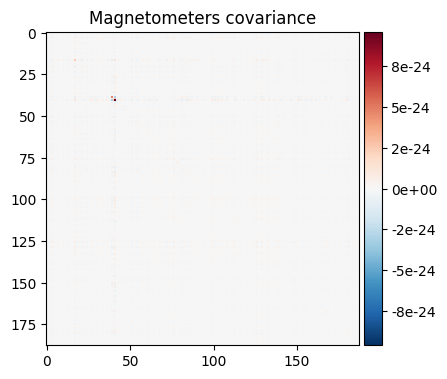

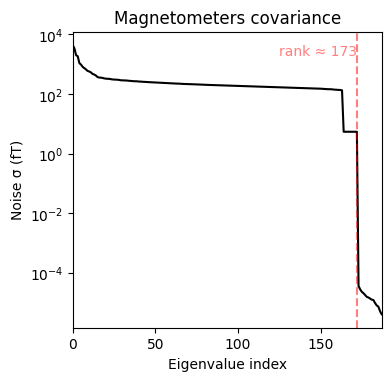

In [8]:
# Visualize the noise covariance matrix and its singular value spectrum.
# See the markdown cell above for a full explanation of what this matrix is,
# how it was created, and how it is used in this notebook.

fig_cov, fig_svd = noise_cov.plot(
    info=evokeds[0].info,
    show_svd=True,
    show=False
)
print('Left: noise covariance matrix (sensors × sensors)')
print('Right: singular value spectrum — ideally should decay smoothly')
print('       A sudden drop-off indicates rank deficiency → may need regularization')


## 3e. Sensor-level Evoked — sanity check before projecting to source space

Available conditions: ['standard_onset', 'deviant_onset', 'deviant_onset - standard_onset']


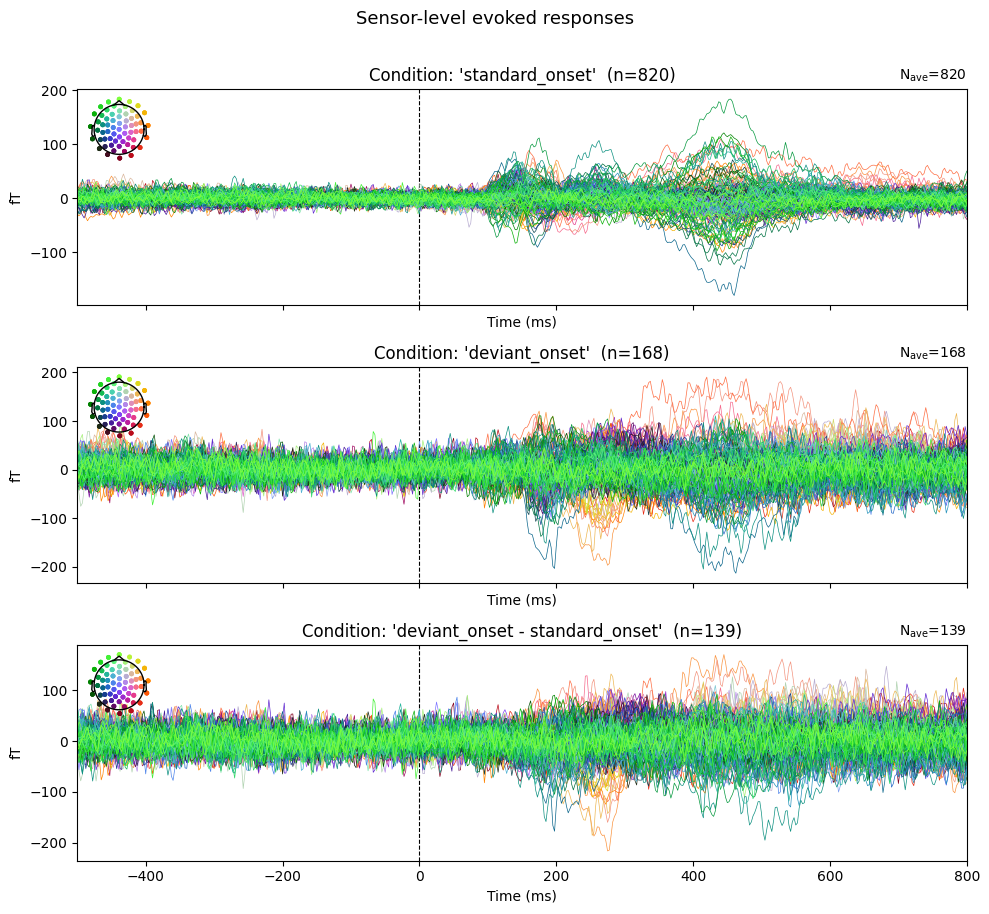

In [9]:
# Find standard, deviant, and MMN evoked objects
# (comment names depend on your config — adjust if needed)
evoked_dict = {ev.comment: ev for ev in evokeds}
print("Available conditions:", list(evoked_dict.keys()))

# Plot all conditions
fig, axes = plt.subplots(len(evokeds), 1, figsize=(10, 3 * len(evokeds)), sharex=True)
if len(evokeds) == 1:
    axes = [axes]

for ax, ev in zip(axes, evokeds):
    ev.plot(axes=ax, show=False, time_unit='ms')
    ax.set_title(f"Condition: {ev.comment!r}  (n={ev.nave})")
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8)

plt.suptitle("Sensor-level evoked responses", fontsize=13, y=1.01)
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    plt.tight_layout()
plt.show()

## 3f. Coregistration — sensors aligned to MRI?

This is one of the most important sanity checks. The sensors should sit on the scalp surface, not floating in air or embedded inside the head.

In [10]:
# Visualise sensor positions in relation to the head surfaces
# If coregistration succeeded, OPM sensors should hug the scalp

# We need the trans file (head <-> MRI transform) to overlay MRI surfaces
# in head coordinates. Search the same roots as other pipeline files.
trans_path = find_deriv('*trans*.fif')
if trans_path.exists():
    print(f'Trans file found: {trans_path}')
    trans = mne.read_trans(trans_path)
else:
    print('⚠️  No trans file found — plotting sensors only (no MRI surfaces).')
    print('   Check that coregistration was run and saved a *trans*.fif file.')
    trans = None

# If we have a trans, plot sensors + MRI surfaces together
# If not, fall back to sensors-only (still useful to check sensor geometry)
surfaces = {'head-dense': 0.9, 'inner_skull': 0.3} if trans is not None else {}

fig = mne.viz.plot_alignment(
    info=evokeds[0].info,
    trans=trans,
    subject=fs_subject,
    subjects_dir=SUBJECTS_DIR,
    surfaces=surfaces,
    meg=True,
    eeg=False,
    dig=True,          # ← white color digitization points of head/wool cap
    coord_frame='head',
    show_axes=True,
)
mne.viz.set_3d_view(fig, azimuth=135, elevation=80, distance=0.6)
print("Sensors (coloured markers) should sit on/near the scalp surface (beige mesh).")
print("If sensors look misaligned, coregistration may need to be re-run.")

Trans file found: /Users/markpinsk/opm-projects/oddball/data/oddball/bids/derivatives/analysis1__/sub-001/ses-01/meg/sub-001_ses-01_task-oddball_trans.fif
Sensors (coloured markers) should sit on/near the scalp surface (beige mesh).
If sensors look misaligned, coregistration may need to be re-run.


---
# 4. Pipeline Summary Dashboard
A quick visual summary of what's done and what's next.

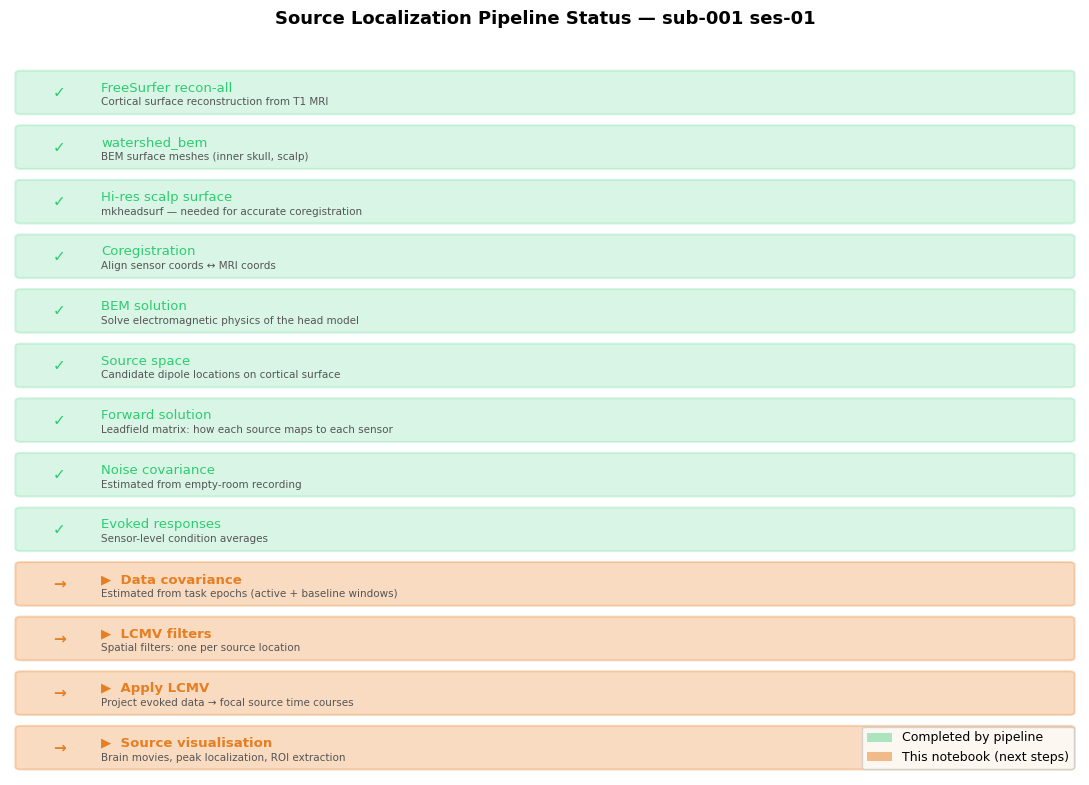

In [11]:
import matplotlib.patches as mpatches

stages = [
    # (label, description, completed_by_pipeline)
    ('FreeSurfer recon-all',     'Cortical surface reconstruction from T1 MRI',            True),
    ('watershed_bem',            'BEM surface meshes (inner skull, scalp)',                True),
    ('Hi-res scalp surface',     'mkheadsurf — needed for accurate coregistration',        True),
    ('Coregistration',           'Align sensor coords ↔ MRI coords',                       True),
    ('BEM solution',             'Solve electromagnetic physics of the head model',        True),
    ('Source space',             'Candidate dipole locations on cortical surface',         True),
    ('Forward solution',         'Leadfield matrix: how each source maps to each sensor',  True),
    ('Noise covariance',         'Estimated from empty-room recording',                    True),
    ('Evoked responses',         'Sensor-level condition averages',                        True),
    ('▶  Data covariance',       'Estimated from task epochs (active + baseline windows)', False),
    ('▶  LCMV filters',          'Spatial filters: one per source location',               False),
    ('▶  Apply LCMV',            'Project evoked data → focal source time courses',        False),
    ('▶  Source visualisation',  'Brain movies, peak localization, ROI extraction',        False),
]

fig, ax = plt.subplots(figsize=(11, len(stages) * 0.55 + 0.8))
ax.set_xlim(0, 10)
ax.set_ylim(-0.5, len(stages))
ax.axis('off')
ax.set_title(f'Source Localization Pipeline Status — {sub_label} {ses_label}',
             fontsize=13, fontweight='bold', pad=10)

for i, (label, desc, done) in enumerate(reversed(stages)):
    y = i
    color  = '#2ecc71' if done else '#e67e22'
    icon   = '✓' if done else '→'
    weight = 'normal' if done else 'bold'

    rect = mpatches.FancyBboxPatch(
        (0.1, y - 0.35), 9.8, 0.7,
        boxstyle='round,pad=0.05',
        facecolor=color, alpha=0.18 if done else 0.28,
        edgecolor=color, linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(0.4, y, icon, fontsize=11, color=color, va='center', fontweight='bold')
    ax.text(0.85, y + 0.08, label, fontsize=9.5, color=color, va='center', fontweight=weight)
    ax.text(0.85, y - 0.18, desc, fontsize=7.5, color='#555555', va='center')

done_patch = mpatches.Patch(facecolor='#2ecc71', alpha=0.4, label='Completed by pipeline')
todo_patch = mpatches.Patch(facecolor='#e67e22', alpha=0.5, label='This notebook (next steps)')
ax.legend(handles=[done_patch, todo_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


---
# 5. Beamformer Source Localization (LCMV)

## Background: approaches to the inverse problem

Recall that the inverse problem is fundamentally ill-posed — many source configurations can produce identical sensor readings. Different methods resolve this ambiguity with different assumptions:

### Minimum Norm Estimate (MNE)
Finds the source distribution with the **smallest total power** that explains the data. Simple and robust, but produces spatially smeared, overly distributed activation, and systematically underestimates deep sources.

### dSPM (dynamic Statistical Parametric Mapping)
A noise-normalized version of MNE. Each source estimate is divided by its noise standard deviation, producing a z-score-like statistic. Corrects for MNE's superficial bias, but the output is still distributed rather than focal. Best applied to evoked (averaged) data.

### sLORETA / eLORETA
Further normalizations of MNE. sLORETA has the theoretical property of zero localization error for a single point source. eLORETA additionally has exact zero error for extended sources. Both are still smooth/distributed like MNE.

### Beamformers (LCMV, DICS)
A fundamentally different philosophy. Rather than solving for all sources simultaneously, a beamformer builds a **spatial filter** for each location: a weighted combination of sensors that maximally passes activity from the target location while suppressing everything else — like a noise-cancelling microphone aimed at one spot in the brain.

- **LCMV** (Linearly Constrained Minimum Variance) — time domain; used with evoked responses
- **DICS** (Dynamic Imaging of Coherent Sources) — frequency domain; used with oscillatory activity

### Comparison

| | MNE | dSPM | sLORETA | LCMV beamformer |
|---|---|---|---|---|
| **Spatial resolution** | Broad | Broad | Broad | Focal |
| **Deep sources** | Underestimated | Partially corrected | Better | Good |
| **Input needed** | Evoked + noise cov | Evoked + noise cov | Evoked + noise cov | Evoked + **data cov** |
| **Correlated sources** | Handles well | Handles well | Handles well | Can suppress |
| **Output** | Distributed map | Noise-normalized map | Noise-normalized map | Focal point estimates |
| **Common use** | General purpose | EEG/MEG evoked | EEG/MEG evoked | **OPM-MEG, MEG oscillations** |

### Why beamformers for OPM-MEG?
OPM sensors sit very close to the scalp, giving high spatial resolution — but that also means the forward model is very sensitive to the exact geometry of each sensor. Beamformers exploit this rich spatial information well, and their ability to suppress spatially structured interference (like environmental noise or reference field fluctuations) is particularly valuable for OPM systems that lack the magnetic shielding of traditional cryogenic MEG rooms.


In [12]:
from mne.beamformer import make_lcmv, apply_lcmv

# ── Load epochs (needed to compute data covariance) ──────────────────────────
# LCMV uses the data covariance (from actual task epochs), not the empty-room
# noise covariance used by dSPM. This captures the actual sensor signal structure.
epochs_path = find_deriv('*epo*.fif')
if not epochs_path.exists():
    raise FileNotFoundError(
        f"Epochs file not found. Searched with pattern '*epo*.fif'.\n"
        f"Check DERIV_DIR: {DERIV_DIR}"
    )
print(f"Epochs file: {epochs_path}")
epochs = mne.read_epochs(epochs_path, preload=True, verbose=False)
print(epochs)

Epochs file: /Users/markpinsk/opm-projects/oddball/data/oddball/bids/derivatives/analysis1__/sub-001/ses-01/meg/sub-001_ses-01_task-oddball_epo.fif
<EpochsFIF | 1000 events (all good), -0.5 – 0.8 s (baseline off), ~872.4 MiB, data loaded, with metadata,
 'deviant_onset': 169
 'standard_onset': 831>


In [13]:
# ── Select evoked conditions for apply_lcmv ─────────────────────────────────
# evoked_standard.info is also used by make_lcmv for channel/sensor metadata.

# ── Select evoked conditions ──────────────────────────────────────────────────
print("Available evoked conditions:")
for k in evoked_dict.keys():
    print(f"  {k!r}")

# Copy the exact strings printed above into these three variables
STANDARD_KEY = 'standard_onset (preceding-deviant matched)'  # <-- edit me
DEVIANT_KEY  = 'deviant_onset'                               # <-- edit me
MMN_KEY      = 'MMN context-matched (deviant - preceding standard)'  # <-- edit me
# ─────────────────────────────────────────────────────────────────────────────

evoked_standard = evoked_dict[STANDARD_KEY]
evoked_deviant  = evoked_dict[DEVIANT_KEY]
evoked_mmn      = evoked_dict[MMN_KEY]

print(f"\nSelected:")
print(f"  Standard : {STANDARD_KEY!r}  (n={evoked_standard.nave})")
print(f"  Deviant  : {DEVIANT_KEY!r}  (n={evoked_deviant.nave})")
print(f"  MMN      : {MMN_KEY!r}")


Available evoked conditions:
  'standard_onset'
  'deviant_onset'
  'deviant_onset - standard_onset'


KeyError: 'standard_onset (preceding-deviant matched)'

In [ ]:
import warnings

# ── Which trials should go into the covariance? ──────────────────────────────
#
# You might expect we should use only the context-matched trials (169 deviant +
# 169 matched standard) so the covariance reflects our exact contrast. However,
# there is a practical problem: a full covariance matrix for 188 channels needs
# MORE trials than channels to be full-rank. With only 169 trials we are
# under-determined — the matrix will be rank-deficient and the beamformer
# weights will be numerically unstable.
#
# The better approach is to use ALL 1000 trials. This is valid because:
#   1. The LCMV filters are meant to capture the general electromagnetic
#      structure of the sensor array, not be tuned to one specific condition.
#   2. We apply one fixed set of filters to pre-averaged evokeds, so condition
#      imbalance in the covariance does not bias the final source estimates.
#   3. More trials → better conditioned matrix → more stable filters.
#
# The condition imbalance (831 standard vs 169 deviant) would only be a
# concern if we were computing separate per-condition power maps and comparing
# them directly — which we are not doing here.
#
EPOCHS_STANDARD_KEY = 'standard_onset'  # <-- edit me (epoch-level label)
EPOCHS_DEVIANT_KEY  = 'deviant_onset'   # <-- edit me (epoch-level label)

epochs_contrast = epochs[EPOCHS_STANDARD_KEY, EPOCHS_DEVIANT_KEY]
print(f'Epochs for covariance: {len(epochs_contrast)} trials')
print(epochs_contrast)

# ── Compute data covariance ───────────────────────────────────────────────────
# Active window: wide enough to capture the full response but not the baseline.
# Baseline window: pre-stimulus period for NAI normalization.
#
# Note: the 'not baseline corrected' warning is expected — we are intentionally
# computing covariance over the active period, not a baseline.
with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    data_cov = mne.compute_covariance(
        epochs_contrast, tmin=0.0, tmax=0.5, method='empirical', verbose=False
    )
    baseline_cov = mne.compute_covariance(
        epochs_contrast, tmin=-0.2, tmax=0.0, method='empirical', verbose=False
    )

print('Data covariance:')
print(data_cov)
print('\nBaseline covariance (pre-stimulus):')
print(baseline_cov)

# Plot both covariances to sanity-check
with warnings.catch_warnings():
    warnings.simplefilter('ignore', UserWarning)
    data_cov.plot(epochs_contrast.info, show=False)
    plt.suptitle('Data covariance (0–500 ms)', y=1.01)
    plt.tight_layout()
    plt.show()

    baseline_cov.plot(epochs_contrast.info, show=False)
    plt.suptitle('Baseline covariance (−200–0 ms)', y=1.01)
    plt.tight_layout()
    plt.show()


In [ ]:
# ── Make LCMV beamformer filters ──────────────────────────────────────────────
# make_lcmv() computes the spatial filter weights for every source location.
# These weights are then applied to any evoked response.
#
# Key parameters:
#   data_cov     — covariance of the signal we want to localize
#   noise_cov    — noise model (used for regularization / NAI normalization)
#   pick_ori     — 'max-power': collapse 3 orientations to the one with max power
#                  'normal':   use only the surface-normal component (like dSPM)
#                  None:       keep all 3 orientations (returns vector STC)
#   reg          — regularization fraction (0.05 = 5%); higher = more stable
#                  but blurrier. Try 0.05–0.1 for OPM-MEG.

filters = make_lcmv(
    evoked_standard.info,
    fwd,
    data_cov,
    reg=0.05,
    noise_cov=noise_cov,
    pick_ori='max-power',
    weight_norm='nai',     # Neural Activity Index: normalizes by baseline noise
    rank=None,
    verbose=False
)
print("LCMV filters computed:")
print(filters)

# Save filters for reuse
filters_path = DERIV_DIR / f"{sub_label}_{ses_label}_task-{TASK}-lcmv.h5"
filters.save(filters_path, overwrite=True)
print(f"\nSaved: {filters_path}")

In [ ]:
# ── Apply LCMV filters to evoked responses ────────────────────────────────────
stc_lcmv_standard = apply_lcmv(evoked_standard, filters, verbose=False)
stc_lcmv_deviant  = apply_lcmv(evoked_deviant,  filters, verbose=False)
stc_lcmv_mmn      = apply_lcmv(evoked_mmn,      filters, verbose=False)

print(f"LCMV source estimates:")
print(f"  Standard : {stc_lcmv_standard.data.shape}  (sources × timepoints)")
print(f"  Deviant  : {stc_lcmv_deviant.data.shape}")
print(f"  MMN      : {stc_lcmv_mmn.data.shape}")

# Save
for stc, name in [(stc_lcmv_standard, 'standard'), (stc_lcmv_deviant, 'deviant'), (stc_lcmv_mmn, 'mmn')]:
    stc_path = DERIV_DIR / f"{sub_label}_{ses_label}_task-{TASK}_lcmv-{name}"
    stc.save(stc_path, overwrite=True)
    print(f"  Saved: {stc_path}-lh.stc")

In [ ]:
# ── Visualize LCMV MMN on brain surface ───────────────────────────────────────
peak_vertex_lcmv, peak_time_lcmv = stc_lcmv_mmn.get_peak(
    hemi='lh', tmin=0.100, tmax=0.250, mode='abs'
)
print(f"LCMV MMN peak: vertex {peak_vertex_lcmv} at {peak_time_lcmv*1000:.1f} ms (LH)")

brain = stc_lcmv_mmn.plot(
    subject=fs_subject,
    subjects_dir=SUBJECTS_DIR,
    hemi='both',
    surface='inflated',
    time_viewer=True,
    colormap='hot',
    clim=dict(kind='percent', lims=[90, 95, 99]),
    title=f'LCMV MMN source estimate',
    initial_time=peak_time_lcmv,
)

---
# 6. What's Left / Next Steps

| Step | Description | Prerequisite |
|------|-------------|-------------|
| ✅ Data covariance | Computed from task epochs (active + baseline) | Epochs |
| ✅ LCMV filters | Spatial filters for all 8196 source locations | Forward + data cov |
| ✅ Source estimates | Standard, deviant, MMN STCs saved | LCMV filters |
| ✅ Sanity check | Peak in auditory cortex? Time course plausible? | STCs |
| ⏭ More subjects | Run pipeline for sub-002, sub-003... | Raw data |
| ⏭ Morph to fsaverage | Map each subject's STC to common brain | STCs + `compute_source_morph()` |
| ⏭ Group average | Average STCs across subjects in fsaverage space | Morphed STCs |
| ⏭ Source-space stats | Cluster permutation test on MMN | Group STCs |
| ⏭ DICS beamformer | Frequency-domain beamformer for oscillatory activity | Epochs |

The core sanity check: **does the MMN peak land in bilateral superior temporal cortex around 100–200 ms?** If yes, your pipeline is working end-to-end. 🎉
